In [23]:
import os
import sys
from dotenv import load_dotenv
load_dotenv
from langchain_ollama import ChatOllama
sys.path.insert(0, os.path.abspath('..'))
from src.agentic.tools import NOTEBOT_TOOLS

In [24]:
llm = ChatOllama(
    model="gemma4:e2b-mlx",
    reasoning=False,
    temperature=0.0,
    top_p=0.5
)

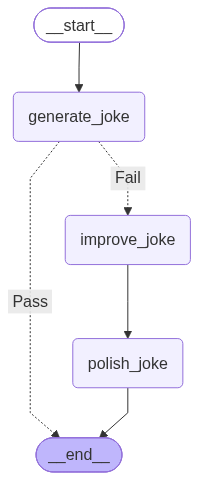

Initial joke:
Why did the car break up with the road a road was a dead end

--- --- ---

Improved joke:
Here are a few options for making that joke funnier with wordplay, playing on different angles:

**Option 1 (Focusing on "Dead End" as a relationship term):**

> "Why did the car break up with the road? Because it realized the road was just a **dead end** in its relationship!"

**Option 2 (Playing on the idea of a dead end being uninteresting/unproductive):**

> "Why did the car break up with the road? Because it found out the road was just a **dead end**—no exciting destinations, just endless stagnation!"

**Option 3 (More Punny/Silly):**

> "Why did the car break up with the road? It said, 'This relationship is a total **dead end**! I need some *turn*!'"

**Option 4 (Short and Punchy):**

> "Why did the car break up with the road? Because it was tired of the **dead-end** commitment!"

**Which one is best depends on your style, but Option 1 or Option 3 usually have the strongest wor

In [ ]:
from typing import Annotated
from ast import operator
from typing import Literal
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from langgraph.checkpoint.memory import InMemorySaver
from langchain.messages import AnyMessage
# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str
    messages: Annotated[list[AnyMessage],operator.add]


# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"Write a short joke about {state['topic']} with no question mark in it")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"Make this joke funnier by adding wordplay: {state['joke']}")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"Add a surprising twist to this joke: {state['improved_joke']}")
    return {"final_joke": msg.content}


# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
checkpointer = InMemorySaver()

chain = workflow.compile(checkpointer=checkpointer)

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

config = {'configurable': {'thread_id': 'lg0'}}
# Invoke
state = chain.invoke({"topic": "cars"},config=config)
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

In [31]:
chain.get_state(config=config)

StateSnapshot(values={'topic': 'cars', 'joke': 'Why did the car break up with the road a road was a dead end', 'improved_joke': 'Here are a few options for making that joke funnier with wordplay, playing on different angles:\n\n**Option 1 (Focusing on "Dead End" as a relationship term):**\n\n> "Why did the car break up with the road? Because it realized the road was just a **dead end** in its relationship!"\n\n**Option 2 (Playing on the idea of a dead end being uninteresting/unproductive):**\n\n> "Why did the car break up with the road? Because it found out the road was just a **dead end**—no exciting destinations, just endless stagnation!"\n\n**Option 3 (More Punny/Silly):**\n\n> "Why did the car break up with the road? It said, \'This relationship is a total **dead end**! I need some *turn*!\'"\n\n**Option 4 (Short and Punchy):**\n\n> "Why did the car break up with the road? Because it was tired of the **dead-end** commitment!"\n\n**Which one is best depends on your style, but Option